# VascX + EyeLiner — longitudinal registration

Align every follow-up visit to the first visit per `(patient, eye)`. Save aligned masks + per-visit `theta`; aligned RGB is reproducible on-demand.

Inputs default to the bundled `samples/` directory.

## 0. Imports and paths

In [1]:
import importlib
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm

from rtnls_fundusprep.preprocessor import parallel_preprocess
from rtnls_inference import (
    ClassificationEnsemble,
    HeatmapRegressionEnsemble,
    RegressionEnsemble,
    SegmentationEnsemble,
)
from rtnls_inference.utils import decollate_batch

c:\Users\Boa\anaconda3\envs\automorph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
PROJECT_ROOT = Path('..').resolve()
SRC_IMAGES   = PROJECT_ROOT / 'samples' / 'images'
CSV_PATH     = PROJECT_ROOT / 'samples' / 'sample_clinical.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'samples' / 'output'
WEIGHTS_ROOT = PROJECT_ROOT / 'weights' / 'vascx'
EYELINER_ROOT = PROJECT_ROOT / 'EyeLiner'

SQUARE_SIZE = 512

prep_root = OUTPUT_ROOT / f'preprocessed_{SQUARE_SIZE}'
rgb_path  = prep_root / 'rgb'
ce_path   = prep_root / 'ce'

out_root     = OUTPUT_ROOT / f'vascx_output_{SQUARE_SIZE}'
av_path      = out_root / 'av'
vessels_path = out_root / 'vessels'
discs_path   = out_root / 'discs'

aligned_root = OUTPUT_ROOT / f'aligned_{SQUARE_SIZE}'

for p in [rgb_path, ce_path, av_path, vessels_path, discs_path, aligned_root]:
    p.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:        ', device, '| square_size:', SQUARE_SIZE)
print('src images:    ', SRC_IMAGES)
print('clinical csv:  ', CSV_PATH)
print('preprocessed:  ', prep_root)
print('vascx output:  ', out_root)
print('aligned root:  ', aligned_root)

## 1. Load clinical CSV and select cohort

In [3]:
data = pd.read_csv(CSV_PATH, low_memory=False)

counts = data.groupby('ID').size().sort_values(ascending=False)
TOP_N = min(3, counts.size)
patient_ids = counts.head(TOP_N).index.tolist()
print(f'patients in csv: {data["ID"].nunique():,}, images: {len(data):,}')
print(f'selected top-{TOP_N} by visit count:')
for pid in patient_ids:
    print(f'  ID={pid}: {counts[pid]} images')

patients in csv: 1, images: 3
selected top-1 by visit count:
  ID=SAMPLE: 3 images


In [4]:
cohort = data[data['ID'].isin(patient_ids)].copy()
cohort['LAB_DTM'] = pd.to_datetime(cohort['LAB_DTM'])
cohort = cohort.sort_values(['ID', 'LAB_DTM', 'shot']).reset_index(drop=True)
cohort

,ID,Filename,LAB_DTM,shot
0,SAMPLE,pid_1.png,2020-01-15,1
1,SAMPLE,pid_2.png,2021-01-20,1
2,SAMPLE,pid_3.png,2021-07-05,1


## 2. Preprocess → RGB + CE (cached)

In [5]:
files = [SRC_IMAGES / fn for fn in cohort['Filename']]
existing = {p.stem for p in rgb_path.glob('*.png')}
todo = [f for f in files if f.stem not in existing]
print(f'total: {len(files)}, cached: {len(files)-len(todo)}, todo: {len(todo)}')

if todo:
    parallel_preprocess(
        todo, rgb_path=rgb_path, ce_path=ce_path,
        square_size=SQUARE_SIZE, n_jobs=4,
    )
    print(f'preprocessed: {len(todo)} @ {SQUARE_SIZE}x{SQUARE_SIZE}')
else:
    print('all cached')

total: 3, cached: 0, todo: 3


0it [00:00, ?it/s][Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
3it [00:00, 509.04it/s]


preprocessed: 3 @ 512x512


[Parallel(n_jobs=4)]: Done   3 out of   3 | elapsed:    2.0s finished


In [6]:
ids = [f.stem for f in files]
rgb_paths = [rgb_path / f'{i}.png' for i in ids]
ce_paths  = [ce_path  / f'{i}.png' for i in ids]
missing = [p for p in rgb_paths + ce_paths if not p.exists()]
assert not missing, f'preprocess failed for: {missing[:3]}'
paired_paths = list(zip(rgb_paths, ce_paths))
print(f'{len(paired_paths)} image pairs ready')

3 image pairs ready


## 3. Load VascX models (7 ensembles)

In [ ]:
ensemble_quality  = ClassificationEnsemble.from_release(str(WEIGHTS_ROOT/'quality.pt')).to(device).eval()
ensemble_av       = SegmentationEnsemble.from_release(str(WEIGHTS_ROOT/'av_july24.pt')).to(device).eval()
ensemble_vessels  = SegmentationEnsemble.from_release(str(WEIGHTS_ROOT/'vessels_july24.pt')).to(device).eval()
ensemble_disc     = SegmentationEnsemble.from_release(str(WEIGHTS_ROOT/'disc_july24.pt')).to(device).eval()
ensemble_fovea    = HeatmapRegressionEnsemble.from_release(str(WEIGHTS_ROOT/'fovea_july24.pt')).to(device).eval()
ensemble_discedge = HeatmapRegressionEnsemble.from_release(str(WEIGHTS_ROOT/'discedge_july24.pt')).to(device).eval()
ensemble_odfd     = RegressionEnsemble.from_release(str(WEIGHTS_ROOT/'odfd_march25.pt')).to(device).eval()

# Released configs ship with square_size=1024; snap to our SQUARE_SIZE grid
for ens in [ensemble_av, ensemble_vessels, ensemble_disc, ensemble_fovea, ensemble_discedge, ensemble_odfd]:
    tt = ens.config['datamodule'].setdefault('test_transform', {})
    tt['square_size'] = SQUARE_SIZE
    tt.setdefault('resize', SQUARE_SIZE)

print(f'loaded 7 models (square_size → {SQUARE_SIZE})')

## 4. Inference — keypoints, scalars, segmentation masks

In [8]:
df_fovea = ensemble_fovea.predict_preprocessed(paired_paths, ids=ids, num_workers=2, batch_size=8)
df_fovea.columns = ['x_fovea', 'y_fovea']

df_discedge = ensemble_discedge.predict_preprocessed(paired_paths, ids=ids, num_workers=2, batch_size=8)
df_discedge.columns = ['x_discedge', 'y_discedge']

df_odfd = ensemble_odfd.predict_preprocessed([str(p) for p in rgb_paths], ids=ids, num_workers=2, batch_size=8)
df_odfd.columns = ['v_odfd']

# Quality (RGB only, reference metric)
dl_q = ensemble_quality._make_inference_dataloader(
    [str(p) for p in rgb_paths], ids=ids, num_workers=2, preprocess=False, batch_size=16,
)
qids, qrows = [], []
with torch.no_grad():
    for batch in tqdm(dl_q, desc='quality'):
        if len(batch) == 0:
            continue
        im = batch['image'].to(device)
        q = ensemble_quality.predict_step(im).mean(dim=0)
        for it in decollate_batch({'id': batch['id'], 'quality': q}):
            qids.append(it['id'])
            qrows.append(it['quality'].tolist())
df_quality = pd.DataFrame(qrows, index=qids, columns=['q1', 'q2', 'q3'])
print('scalar / keypoint inference done')

FundusTestTransform initialized with contrast_enhance: False


100%|██████████| 1/1 [00:13<00:00, 13.23s/it]


FundusTestTransform initialized with contrast_enhance: False


100%|██████████| 1/1 [00:09<00:00,  9.62s/it]


FundusTestTransform initialized with contrast_enhance: False


100%|██████████| 1/1 [00:09<00:00,  9.29s/it]


FundusTestTransform initialized with contrast_enhance: False


quality: 100%|██████████| 1/1 [00:08<00:00,  9.00s/it]

scalar / keypoint inference done


In [9]:
ensemble_av.predict_preprocessed(paired_paths, ids=ids, dest_path=av_path, num_workers=2, batch_size=8)
ensemble_vessels.predict_preprocessed(paired_paths, ids=ids, dest_path=vessels_path, num_workers=2, batch_size=8)
ensemble_disc.predict_preprocessed(paired_paths, ids=ids, dest_path=discs_path, num_workers=2, batch_size=8)
print('masks:',
      'av',      len(list(av_path.glob('*.png'))),
      'vessels', len(list(vessels_path.glob('*.png'))),
      'disc',    len(list(discs_path.glob('*.png'))))

FundusTestTransform initialized with contrast_enhance: False


100%|██████████| 1/1 [00:09<00:00,  9.88s/it]


FundusTestTransform initialized with contrast_enhance: False


100%|██████████| 1/1 [00:09<00:00,  9.70s/it]


FundusTestTransform initialized with contrast_enhance: False


100%|██████████| 1/1 [00:10<00:00, 10.34s/it]

masks: av 3 vessels 3 disc 3


## 5. Inventory — disc centroid, laterality, grouping

Disc centre from mask centroid (largest blob), fallback to `discedge` keypoint if the mask is empty. Laterality: `disc.x > fovea.x → L`, else `R`.

In [ ]:
from scipy import ndimage as ndi

MIN_SEP_FRAC = 0.02
MIN_DISC_PX  = 50

def disc_geometry(disc_mask, min_area_px=MIN_DISC_PX):
    m = disc_mask.astype(bool)
    if m.sum() < min_area_px:
        return dict(cx=np.nan, cy=np.nan, diameter=np.nan,
                    area_px=float(m.sum()), found=False)
    lab, n = ndi.label(m)
    if n > 1:
        sizes = ndi.sum(m, lab, range(1, n + 1))
        m = lab == (int(np.argmax(sizes)) + 1)
    area = float(m.sum())
    cy, cx = ndi.center_of_mass(m)
    return dict(cx=float(cx), cy=float(cy),
                diameter=2.0 * np.sqrt(area / np.pi),
                area_px=area, found=True)

def determine_laterality(x_fovea, x_disc, W=SQUARE_SIZE, min_frac=MIN_SEP_FRAC):
    sep = x_disc - x_fovea
    if abs(sep) < min_frac * W:
        return 'unknown', sep
    return ('L' if sep > 0 else 'R'), sep

rows = []
for _, r in cohort.iterrows():
    stem = Path(r['Filename']).stem
    if stem not in df_fovea.index or stem not in df_discedge.index:
        continue
    fx, fy = df_fovea.loc[stem, ['x_fovea', 'y_fovea']]

    disc_mask_path = discs_path / f'{stem}.png'
    if disc_mask_path.exists():
        dg = disc_geometry(np.array(Image.open(disc_mask_path)))
    else:
        dg = dict(cx=np.nan, cy=np.nan, diameter=np.nan, area_px=0, found=False)

    if dg['found']:
        dx, dy = dg['cx'], dg['cy']
        disc_source = 'mask'
    else:
        dx = float(df_discedge.loc[stem, 'x_discedge'])
        dy = float(df_discedge.loc[stem, 'y_discedge'])
        disc_source = 'keypoint_fallback'

    eye, sep = determine_laterality(fx, dx)
    q = df_quality.loc[stem].tolist() if stem in df_quality.index else [np.nan] * 3
    rows.append({
        'id': stem, 'patient': r['ID'], 'date': r['LAB_DTM'],
        'shot': r['shot'], 'filename': r['Filename'],
        'eye': eye, 'sep_x': sep,
        'x_fovea': fx, 'y_fovea': fy,
        'x_disc': dx, 'y_disc': dy,
        'disc_diameter': dg['diameter'], 'disc_area_px': dg['area_px'],
        'disc_source': disc_source,
        'x_discedge_kp': float(df_discedge.loc[stem, 'x_discedge']),
        'y_discedge_kp': float(df_discedge.loc[stem, 'y_discedge']),
        'v_odfd': df_odfd.loc[stem, 'v_odfd'] if stem in df_odfd.index else np.nan,
        'q1': q[0], 'q2': q[1], 'q3': q[2],
    })

inv_df = pd.DataFrame(rows).sort_values(['patient', 'eye', 'date', 'shot']).reset_index(drop=True)

n_fallback = (inv_df['disc_source'] == 'keypoint_fallback').sum()
print(f'disc centroid: mask={len(inv_df)-n_fallback}, keypoint fallback={n_fallback}')
print(f'disc_diameter (px): median={inv_df["disc_diameter"].median():.1f}, '
      f'min={inv_df["disc_diameter"].min():.1f}, max={inv_df["disc_diameter"].max():.1f}')
inv_df.to_csv(aligned_root / 'inventory.csv', index=False)
inv_df

In [11]:
inventory = {}
for (pid, eye), grp in inv_df.groupby(['patient', 'eye'], sort=False):
    inventory.setdefault(pid, {})[eye] = grp.to_dict('records')

for pid in patient_ids:
    print(f'\npatient {pid}:')
    for eye, visits in inventory.get(pid, {}).items():
        print(f'  {eye}: {len(visits)} images', [v["date"].strftime("%Y-%m-%d") for v in visits])


patient SAMPLE:
  R: 3 images ['2020-01-15', '2021-01-20', '2021-07-05']


## 6. EyeLiner setup (local `../EyeLiner/`)

In [12]:
if str(EYELINER_ROOT) not in sys.path:
    sys.path.insert(0, str(EYELINER_ROOT))

if 'eyeliner.lightglue' not in sys.modules:
    sys.modules['eyeliner.lightglue']       = importlib.import_module('lightglue')
    sys.modules['eyeliner.lightglue.utils'] = importlib.import_module('lightglue.utils')

from eyeliner import EyeLinerP

EL_SIZE = 256
eyeliner_api = EyeLinerP(
    kp_method='splg', reg='affine',
    image_size=(3, EL_SIZE, EL_SIZE), device=device,
)
print('EyeLinerP ready (local EyeLiner)')

D:\fundus-vessel-features\EyeLiner\lightglue\lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


EyeLinerP ready (local EyeLiner)


## 7. Register per group + save aligned masks

First visit = fixed, rest = moving. Stores aligned `av/vessels/discs` PNGs + `theta` log.

In [13]:
def prep_tensor(img_np, size=EL_SIZE):
    a = cv2.resize(img_np.astype(np.float32) / 255.0, (size, size))
    return torch.tensor(a).permute(2, 0, 1).unsqueeze(0).to(device)

def rescale_theta(theta_256, H, W, size=EL_SIZE):
    S = np.array([[W/size, 0, 0], [0, H/size, 0], [0, 0, 1]], dtype=np.float64)
    return S @ theta_256 @ np.linalg.inv(S)

def warp_image(img, theta, H, W, is_mask=False):
    flags = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    return cv2.warpAffine(img, theta[:2, :], (W, H),
                          flags=flags, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

def register_pair(rgb_fixed, rgb_moving):
    H, W = rgb_fixed.shape[:2]
    tf, tm = prep_tensor(rgb_fixed), prep_tensor(rgb_moving)
    theta, cache = eyeliner_api({'fixed_input': tf, 'moving_input': tm})
    theta = theta.squeeze().cpu().numpy()
    theta_full = rescale_theta(theta, H, W)
    n_kp = cache['kp_fixed'].shape[1]
    return theta_full, n_kp

def save_mask_png(mask, path):
    Image.fromarray(mask).save(path, format='PNG', optimize=True)

In [14]:
def register_group(visits, patient, eye, save_root):
    """Register every visit in a group to the first (fixed) visit and save aligned masks."""
    if len(visits) < 2:
        print(f'  [{patient}/{eye}] only {len(visits)} image(s), skipping registration')
        return []

    out_dir = save_root / str(patient) / eye
    for tag in ['av', 'vessels', 'discs']:
        (out_dir / tag).mkdir(parents=True, exist_ok=True)

    fixed = visits[0]
    fixed_rgb = np.array(Image.open(rgb_path / f'{fixed["id"]}.png'))
    H, W = fixed_rgb.shape[:2]

    # Fixed visit = identity; just copy masks across
    for tag, mask_dir in [('av', av_path), ('vessels', vessels_path), ('discs', discs_path)]:
        m = np.array(Image.open(mask_dir / f'{fixed["id"]}.png'))
        save_mask_png(m, out_dir / tag / f'{fixed["id"]}.png')

    records = [{**fixed, 'is_fixed': True, 'n_kp': np.nan,
                'theta': np.eye(3).flatten().tolist()}]

    for v in visits[1:]:
        moving_rgb = np.array(Image.open(rgb_path / f'{v["id"]}.png'))
        try:
            theta, n_kp = register_pair(fixed_rgb, moving_rgb)
        except Exception as e:
            print(f'  [{patient}/{eye}] {v["id"]} registration failed: {e}')
            continue

        for tag, mask_dir in [('av', av_path), ('vessels', vessels_path), ('discs', discs_path)]:
            m = np.array(Image.open(mask_dir / f'{v["id"]}.png'))
            wm = warp_image(m, theta, H, W, is_mask=True)
            save_mask_png(wm, out_dir / tag / f'{v["id"]}.png')

        records.append({**v, 'is_fixed': False, 'n_kp': n_kp,
                        'theta': theta.flatten().tolist()})
    return records

all_records = []
for pid in patient_ids:
    for eye, visits in inventory.get(pid, {}).items():
        if eye == 'unknown':
            print(f'[{pid}/unknown] laterality undetermined, skipping')
            continue
        print(f'[{pid}/{eye}] fixed={visits[0]["id"]}, moving={len(visits)-1}')
        all_records.extend(register_group(visits, pid, eye, aligned_root))

reg_df = pd.DataFrame(all_records)
if len(reg_df):
    theta_cols = [f't{i}{j}' for i in range(3) for j in range(3)]
    reg_df[theta_cols] = pd.DataFrame(reg_df['theta'].tolist(), index=reg_df.index)
    reg_df = reg_df.drop(columns=['theta'])
reg_df.to_csv(aligned_root / 'registration_log.csv', index=False)
print(f'\nprocessed {len(reg_df)} image(s), log saved to {aligned_root/"registration_log.csv"}')

[SAMPLE/R] fixed=pid_1, moving=2

processed 3 image(s), log saved to D:\fundus-vessel-features\samples\output\aligned_512\registration_log.csv


## 8. Timeline — original / aligned / overlay-vs-fixed

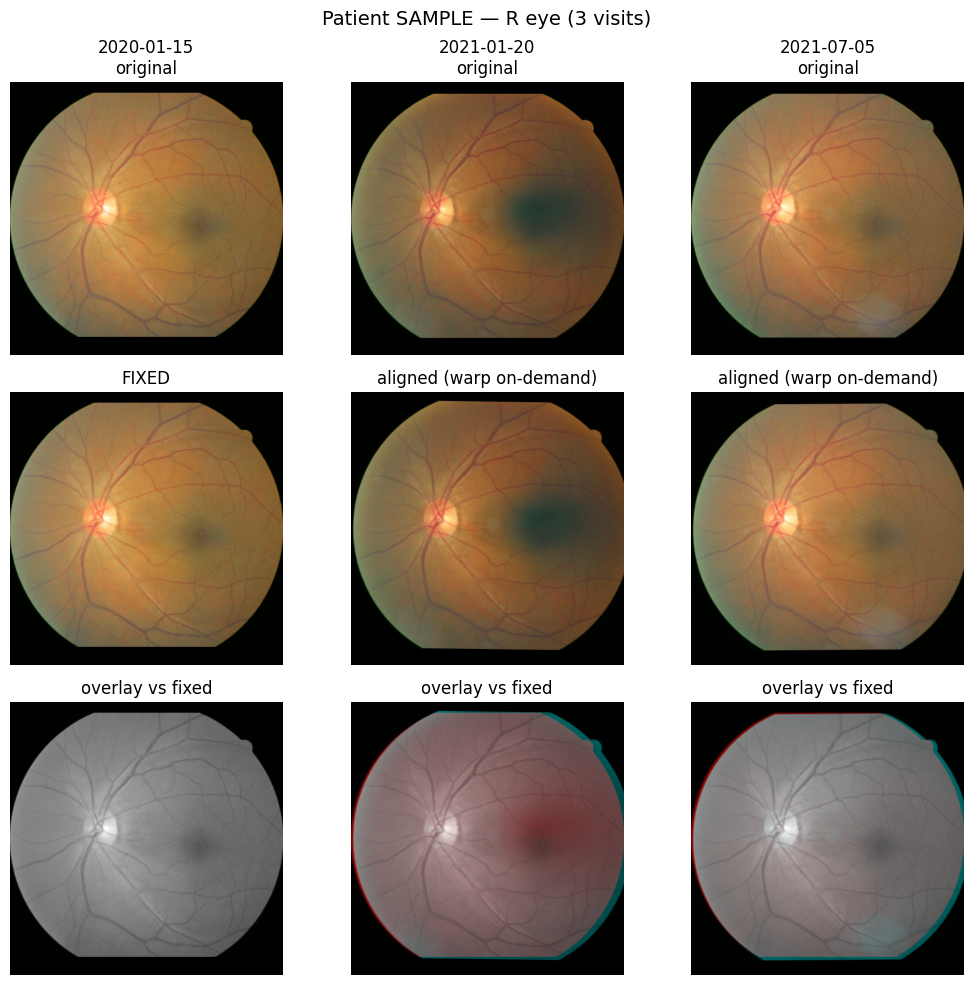

In [15]:
theta_cols = [f't{i}{j}' for i in range(3) for j in range(3)]
def get_theta(image_id):
    row = reg_df[reg_df['id'] == image_id]
    if len(row) == 0:
        return None
    return row.iloc[0][theta_cols].values.astype(np.float64).reshape(3, 3)

def make_overlay(fixed_img, moving_img):
    fg = cv2.cvtColor(fixed_img, cv2.COLOR_RGB2GRAY)
    mg = cv2.cvtColor(moving_img, cv2.COLOR_RGB2GRAY)
    out = np.zeros((*fg.shape, 3), dtype=np.uint8)
    out[..., 0] = fg
    out[..., 1] = mg
    out[..., 2] = mg
    return out

def plot_patient_eye(patient, eye, visits):
    if len(visits) < 2:
        return
    fixed = visits[0]
    fixed_rgb = np.array(Image.open(rgb_path / f'{fixed["id"]}.png'))
    H, W = fixed_rgb.shape[:2]
    n = len(visits)

    fig, axes = plt.subplots(3, n, figsize=(3.5 * n, 10))
    if n == 1:
        axes = axes[:, None]
    for i, v in enumerate(visits):
        orig = np.array(Image.open(rgb_path / f'{v["id"]}.png'))
        axes[0, i].imshow(orig)
        axes[0, i].set_title(f'{v["date"].strftime("%Y-%m-%d")}\noriginal')

        if i == 0:
            aligned = fixed_rgb
            axes[1, i].set_title('FIXED')
        else:
            theta = get_theta(v['id'])
            if theta is None:
                for r in [1, 2]:
                    axes[r, i].axis('off')
                    axes[r, i].set_title('(skipped)')
                continue
            aligned = warp_image(orig, theta, H, W)
            axes[1, i].set_title('aligned (warp on-demand)')

        axes[1, i].imshow(aligned)
        axes[2, i].imshow(make_overlay(fixed_rgb, aligned))
        axes[2, i].set_title('overlay vs fixed')

    for ax in axes.flat:
        ax.axis('off')
    fig.suptitle(f'Patient {patient} — {eye} eye ({n} visits)', fontsize=14)
    plt.tight_layout()
    plt.show()

for pid in patient_ids:
    for eye, visits in inventory.get(pid, {}).items():
        if eye != 'unknown':
            plot_patient_eye(pid, eye, visits)

## 9. Aligned AV mask overlay check

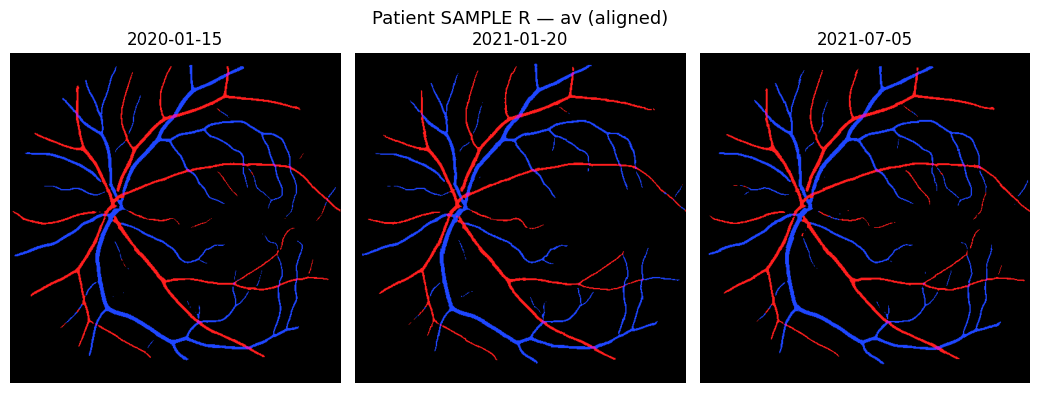

In [16]:
def plot_mask_timeline(patient, eye, visits, mask_tag='av'):
    if len(visits) < 2:
        return
    mdir = aligned_root / str(patient) / eye / mask_tag
    fig, axes = plt.subplots(1, len(visits), figsize=(3.5 * len(visits), 4))
    if len(visits) == 1:
        axes = [axes]
    for i, v in enumerate(visits):
        p = mdir / f'{v["id"]}.png'
        if not p.exists():
            axes[i].axis('off')
            continue
        mask = np.array(Image.open(p))
        if mask_tag == 'av':
            # 0=bg, 1=A (red), 2=V (blue), 3=crossing (magenta)
            rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
            rgb[mask == 1] = [255, 30, 30]
            rgb[mask == 2] = [30, 70, 255]
            rgb[mask == 3] = [200, 30, 200]
            axes[i].imshow(rgb)
        else:
            axes[i].imshow(mask, cmap='gray')
        axes[i].set_title(v['date'].strftime('%Y-%m-%d'))
        axes[i].axis('off')
    fig.suptitle(f'Patient {patient} {eye} — {mask_tag} (aligned)', fontsize=13)
    plt.tight_layout()
    plt.show()

for pid in patient_ids:
    for eye, visits in inventory.get(pid, {}).items():
        if eye != 'unknown':
            plot_mask_timeline(pid, eye, visits, 'av')

## 10. Outputs

Under `samples/output/aligned_512/`:
- `<patient>/<eye>/{av,vessels,discs}/*.png`
- `inventory.csv`, `registration_log.csv`

Feature extraction continues in `02-features-align.ipynb`.